# EBA 3630 Data Driven Management Accounting EXAM

## Table of Contents

* [Exercise 1: Performance Measurement](#Exercise-1:-Performance-Measurement)
    
    - [1: My opinion on Luke's graph](#1:-My-opinion-on-Luke's-graph)
    
    - [2: Balanced Scorecard](#2:-Balanced-Scorecard)
    
    - [3: Analyse of the Balanced Scorecard](#3:-Analyse-of-the-Balanced-Scorecard)
    
* [Exercise 2: Prediction](#Exercise-2:-Prediction)

    - [1: Variables](#1:-Variables)
    
    - [2: Decision Tree](#2:-Decision-Tree)
    
    - [3: Most Important Features](#3:-Most-Important-Features)
    
    - [4: Visualization](#4:-Visualization)
    
    - [5: Classify a Customer](#5:-Classify-a-Customer)
    
    - [6: Which Option Should SustainaKitchen Apply?](#6:-Which-Option-Should-SustainaKitchen-Apply?)
    
    - [7: Larger Potential Customer Base](#7:-Larger-Potential-Customer-Base)
    
* [Exercise 3: Cost Estimation](#Exercise-3:-Cost-Estimation)

    - [My Recommendation](#My-Recommendation)

* [Exercise 4: Forensic Accounting and Cybersecurity](#Exercise-4:-Forensic-Accounting-and-Cybersecurity)

    - [1: The Number of Emails Sent Each Hour of the Day](#1:-The-Number-of-Emails-Sent-Each-Hour-of-the-Day)
    
    - [2: Competing Firms](#2:-Competing-Firms)
    
    - [3: Test Question](#3:-Test-Question)

## Importing Modules and Packages

In [202]:
import pandas as pd
import ipywidgets
import re

from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score

import plotly.graph_objects as go
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

## Exercise 1: Performance Measurement

### Questions

### 1: My opinion on Luke's graph

When giving my opinion on Luke's graph, it's important to judge it based off of Luke's objective, which was to **"create a visualization that depicts the distribution of customers across different age groups"**.

While Luke has incorporated some useful features, such as colors and some axis labels, the overall graph lacks clarity and is challenging to interpret. The use of a 3D bar chart adds unnecessary complexity and makes it harder to extract meaningful insights. Specifically, the axis with the values 0-6 does not contribute effectively to the visualization. Due to its lack of an axis label, it instead creates confusion.

Additionally, the order of the age groups is determined by the number of customers in each group. While this may seem logical, it actually reduces the graph's intuitiveness. The readers must continuously compare the age groups with the number of customers, rather than being able to follow a natural, logical progression, such as ordering the age groups from youngest to oldest or vice versa.

When visualizing data, simplicity is more effective in communicating information clearly. In this case, a simpler approach would have been better suited to achieve the objective. I recommend presenting this data using a 2D bar chart, which would make the distribution of customers across age groups much easier to understand at a glance.

Another important recommendation would be to organize the age groups sequentially, either from youngest to oldest or in reverse order. This structure would provide a more intuitive understanding of the data and allow viewers to quickly grasp the distribution. Different colors aren't necessary, unless the specific age groups are to be analysed. But this is arbitrary.

As to whether Luke has fulfilled his objective, I would say that while the data is technically represented, the complexity of the chart contradicts from its effectiveness. Simplifying the visualization to a 2D bar chart and sort the age groups sequentially would improve its clarity and ensure that the objective is achieved without overwhelming or confusing the readers.

### 2: Balanced Scorecard

Visualize the balanced scorecard in an **interactive** manner, allowing for the selection of specific **quarters** for display. Additionally, include **colored performance markers** to indicate the extent to which targets are met. Specifically, use the color **green** when the target is met or exceeded, **orange** when the target is missed by no more than 10%, and **red** when the target is not met at all.

In [203]:
bs = pd.read_excel(r'/Users/isabellejacobsen/portfolio/Exercise1.xlsx')
bs.head(10)

,Perspective,Strategic Objectives,Measure,Target Performance,Actual Performance,Quarter
0,Financial,Increase revenue,operating income,12000.00,5000.00,1
1,Financial,Increase revenue,operating income,15000.00,7000.00,2
2,Financial,Increase revenue,operating income,20000.00,10000.00,3
3,Financial,Increase revenue,operating income,25000.00,12000.00,4
4,Customer Perspective,Acquire and retain customers,customer-retention percentage,0.10,0.05,1
5,Customer Perspective,Acquire and retain customers,customer-retention percentage,0.15,0.08,2
6,Customer Perspective,Acquire and retain customers,customer-retention percentage,0.20,0.18,3
7,Customer Perspective,Acquire and retain customers,customer-retention percentage,0.20,0.19,4
8,Customer Perspective,Increase market share,market share,0.05,0.04,1
9,Customer Perspective,Increase market share,market share,0.10,0.05,2


In [204]:
bs['Measure'].unique()

<StringArray>
[              'operating income',  'customer-retention percentage',
                   'market share',        'cycle time (in minutes)',
                   'defect rates', 'hours of training per employee']
Length: 6, dtype: str

In [205]:
bs['Target Diff']     = bs['Target Performance'] - bs['Actual Performance']
bs['Target Diff (%)'] = ((bs['Target Performance'] - bs['Actual Performance']) / bs['Target Performance']) * 100
bs['Target Reached']  = ""

for i in bs.index:
    if bs.loc[i, 'Target Diff'] <= 0:
        bs.loc[i, 'Target Reached'] = "Met/Exceeded"
    elif round(bs.loc[i, 'Target Diff (%)'], 10) <= 10:
        bs.loc[i, 'Target Reached'] = "10% off"
    else:
        bs.loc[i, 'Target Reached'] = "Not Met"

In [206]:
def reached_target(row):    
    fail = 'background-color: tomato;'
    exceed = 'background-color: palegreen;'
    meetc = 'background-color: orange;'
    default = ''

    if row['Target Reached'] == "Met/Exceeded":
        return [default, exceed] 
    elif row['Target Reached'] == "10% off":
        return [default, meetc] 
    else:
        return [default, fail] 

In [207]:
drop_down = ipywidgets.Dropdown(options = list(bs['Quarter'].unique()),
                               value=1,  
                               description = 'Quarter:', 
                               disabled=False,
                               )

In [208]:
bs.columns

Index(['Perspective', 'Strategic Objectives', 'Measure', 'Target Performance',
       'Actual Performance', 'Quarter', 'Target Diff', 'Target Diff (%)',
       'Target Reached'],
      dtype='str')

In [209]:
def balanced_scorecard(quarter):
    bsfilter=bs[bs['Quarter']==quarter]
    bsfilter=bsfilter[['Perspective', 'Strategic Objectives','Measure', 'Target Performance', 'Actual Performance', 'Target Reached']]
    return bsfilter.style.apply(reached_target, subset=['Actual Performance', 'Target Reached'], axis='columns')

ipywidgets.interact(balanced_scorecard, quarter=drop_down);

interactive(children=(Dropdown(description='Quarter:', options=(np.int64(1), np.int64(2), np.int64(3), np.int6…

**Comment:** When deciding the 10% off variable, I noticed that the code 

elif bs['Target Diff (%)'][i] <= 10:

didn't give correct output. In the table, it wasn't able to identify the target difference that was exactly missed by 10% (even though it should, using the less than or equal to sign). Hence, I changed it to 10.00001 so that it would show the correct targets in the table.

### 3: Analyze of the Balanced Scorecard

SustainaKitchen's strategy is to produce eco-friendly non-toxic kitchenware, with a focus on sustainability, innovation and R&D. Its primary focus is to grow as a brand and attract a wider customer base, without losing sight of their environmental goals. As a new startup, the company is in the growth stage of its business life cycle.

When analysing the balanced scoreboard, it's important to do so from the four perspectives: "*financial*", "*customer*", "*internal business process*" and "*learning and growth*".

**Financial:** 
    
The objective is to increase revenue. In all four quarters, the target performance is not met by approximately 50%. The pricing may be off or there might be a limited market reach.


**Customer:**
    
The objective is to acquire and retain customers and increase market share. The target performance is also not met in all four quarters, however, the actual performance is 10% off the two last quarters in customer retention percentage. This shows that there is low customer engagement, with some improvement towards the end.

**Internal business process:** 

The objective is to improve manufacturing quality and productivity. The cycle time targets were consistently met or exceeded, while the defect rates improved throughout the quarters, meeting targets by quarter four.

**Learning and growth:**

The objective is to increase employee efficiency and productivity. The training hours per employee was 10% off at the first quarter, but was consistently met or exceeded the last three quarters.

**My recommendations to Maria based on the balanced scorecard would be the following:**

**Financial**
- Launch marketing campaigns to boost sales and explore partnerships or promotions to reach a wider audience. Consider the price to reflect product value and demand.

**Customer**
- Promote the sustainability benefits of the products to attract eco-aware customers and invest in digital marketing to expand the customer base.

**Internal Business Process**
- Maintain focus on efficiency and quality improvements.

**Learning and Growth**
- Continue the success in training and employee development.

In conclusion, the current balanced scorecard aligns well with SustainaKitchen's strategy and growth stage. Its focus on sustainability, innovation and expansion shows its strategic priorities. However, underperformance in revenue and customer reach highlights the need for focus on marketing and customer relations. Addressing these issues will be key to acheiving the company's goals.

## Exercise 2: Prediction

In [210]:
pc = pd.read_csv('Exercise2.csv')
pc.head(10)

,Paid,AreaType,AvgIncome,Age,LateFees,Gender,UnemployRate,Newsletter,EmailDomain
0,Default,Urban,40242.77,21,0,Female,0.16,No,gmail.com
1,Default,Rural,47496.28,24,0,Female,0.18,No,icloud.com
2,Default,Suburban,77776.38,33,0,Male,0.02,No,yandex.com
3,Default,Urban,46522.53,26,0,Male,0.02,No,aol.com
4,Paid,Urban,92252.69,37,0,Female,0.02,Yes,gmail.com
5,Paid,Urban,68577.59,32,0,Female,0.02,No,icloud.com
6,Default,Urban,71711.89,37,117,Male,0.02,No,gmail.com
7,Paid,Rural,64432.54,33,0,Unknown,0.02,No,yahoo.com
8,Paid,Suburban,85456.96,41,0,Female,0.02,No,yandex.com
9,Default,Suburban,85663.20,43,0,Male,0.01,Yes,yandex.com


### Questions

### 1: Variables

SustainaKitchen wants to predict whether a new customer is likely to default or not, so the dependent variable is **paid**. This is the dependent variable because the prediction is dependent on whether the paid status is default or paid.

**The independent variables are:**
- AvgIncome
    - Reflects the average income in the customer's area and serves as an overview for their financial capacity. Customers from higher-income areas are more likely to have the resources necessary to pay on account, reducing the possibility of default.
- Age
    - Can correlate with financial stability and economic responsibility. Elders usually have more stable incomes or financial planning experience, whereas younger people have less predictable payment behaviors.
- LateFees
    - Accumulated late fees directly reflect a customer’s historical payment behavior. Customers with existing late fees may exhibit a pattern of missing payments, making them more likely to default again.
- UnemployRate
    - The unemployment rate in the customer’s area is a critical economic indicator. High unemployment rates may correlate with greater financial stress among customers, increasing the probability of default.

**I have decided on leaving out:**
- AreaType
    - The residential area type may provide some insights, but its impact is captured by the unemployment rate.
- Gender
    - There is no clear or direct evidence that it impacts financial behavior or payment defaults in this context. There is also an "Unknown" option, which can bring noise.
- Newsletter
    - May reflect customer engagement, but it is not a strong or direct indicator of financial capacity or payment behavior.
- EmailDomain
    - They are unlikely to have a critical or reliable relationship with payment behavior.

These variables are also left out so that there are less bias introduced to the model.

In [211]:
pc.columns

Index(['Paid', 'AreaType', 'AvgIncome', 'Age', 'LateFees', 'Gender',
       'UnemployRate', 'Newsletter', 'EmailDomain'],
      dtype='str')

### 2: Decision Tree

When choosing the independent variables, I have included the ones I mentioned in task **1: Variables**. In the code below, I transformed them into numerical representations using *LabelEncoder*.

In [212]:
# AvgIncome, Age, LateFees, and UnemployRate are already numeric — use them directly.
# Applying LabelEncoder to continuous variables replaces actual values with rank-based
# integers, distorting the feature's meaning for the decision tree.
# LabelEncoder is only needed for the categorical target variable (Paid).

pc['AvgInc_n'] = pc['AvgIncome']
pc['Age_n']    = pc['Age']
pc['LateF_n']  = pd.to_numeric(pc['LateFees'], errors='coerce').fillna(0)
pc['UnempR_n'] = pc['UnemployRate']
pc['Paid_n']   = LabelEncoder().fit_transform(pc['Paid'])
pc.head()

,Paid,AreaType,AvgIncome,Age,LateFees,Gender,UnemployRate,Newsletter,EmailDomain,AvgInc_n,Age_n,LateF_n,UnempR_n,Paid_n
0,Default,Urban,40242.77,21,0,Female,0.16,No,gmail.com,40242.77,21,0,0.16,0
1,Default,Rural,47496.28,24,0,Female,0.18,No,icloud.com,47496.28,24,0,0.18,0
2,Default,Suburban,77776.38,33,0,Male,0.02,No,yandex.com,77776.38,33,0,0.02,0
3,Default,Urban,46522.53,26,0,Male,0.02,No,aol.com,46522.53,26,0,0.02,0
4,Paid,Urban,92252.69,37,0,Female,0.02,Yes,gmail.com,92252.69,37,0,0.02,1


**Paid** is the target variable, which is why I set it as y. The dataset is split using the *train_test_split*, with *random_state* so that it can be reproduced. It's important to split testing and training data, so that the model's performance can be evaluated on unseen data, reducing the risk of overfitting.

In [213]:
X = pc[['AvgInc_n','Age_n','LateF_n','UnempR_n' ]]
y = pc['Paid_n']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) 

In [214]:
ppc = DecisionTreeClassifier(ccp_alpha=0.0015, random_state=1)
ppc = ppc.fit(X_train, y_train)

In [215]:
scores = cross_val_score(ppc, X, y, cv=10, scoring='accuracy')
print(scores)
scores.mean()

[0.812 0.835 0.852 0.838 0.84  0.835 0.835 0.838 0.858 0.837]


np.float64(0.8379999999999999)

The high accuracy of 83.8% ensures that the model can predict which customers are likely to pay, with a small error margin. I selected the pruning *ccp_alpha* to reduce the complexity of the decision tree, so that the model is less likely to overfit.

### 3: Most Important Features

In [216]:
feature_names = X_train.columns

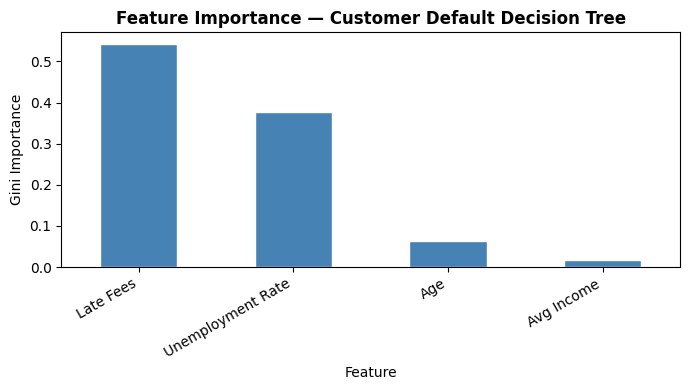

In [217]:
feature_importance = pd.DataFrame(
    ppc.feature_importances_,
    index=['Avg Income', 'Age', 'Late Fees', 'Unemployment Rate'],
    columns=['Importance']
).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
feature_importance['Importance'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Customer Default Decision Tree', fontweight='bold')
ax.set_ylabel('Gini Importance')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

According to my decision tree, the features that are most important for explaining default are **late fees** and **unemployment rate**.

### 4: Visualization

In [218]:
print(ppc.tree_.max_depth)

5


Since the maximum depth of my decision tree is 5, I need to prune it to 4.

In [219]:
ppc1 = DecisionTreeClassifier(ccp_alpha=0.0015, random_state=1, max_depth=4)
ppc1 = ppc1.fit(X_train, y_train)

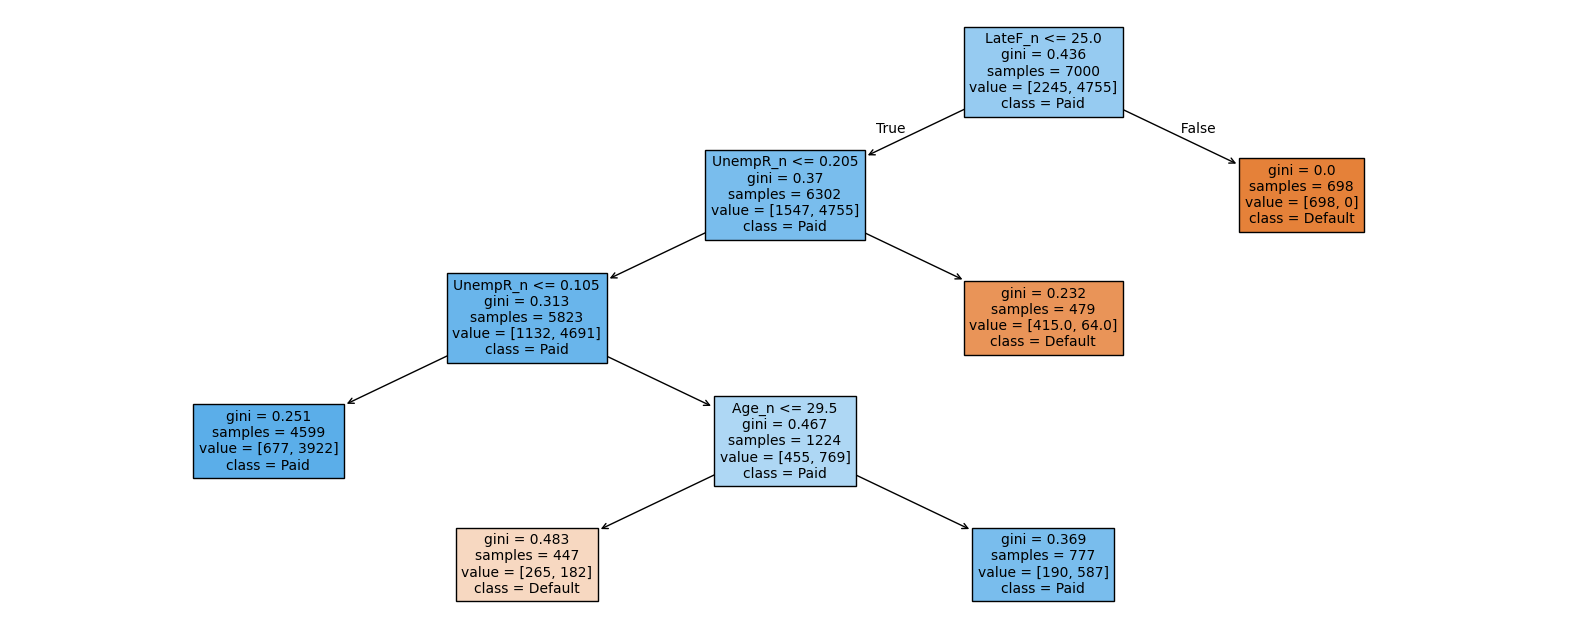

In [220]:
fig = plt.figure(figsize=(20,8))
_ = plot_tree(ppc1,
                  feature_names=feature_names,
                  class_names={0:'Default', 1:'Paid'},
                  filled=True,
                  fontsize=10)

In [221]:
fig.savefig('DecisionTree1.pdf', dpi = 200);

**Comment:** I saved the decision tree model so that I could analyse it closer.

### 5: Classify a Customer

When classifying the customer using the decision tree, I'll follow the node steps by steps:

In the root node we determine whether the customer has LateF_n <= 0.5. The customer has 0 late fees, so it is true.

Following the true arrow, we go to the next node and determine whether the customer has UnempR_n <= 19.5. The customer has 0.1 so it is true.

Again, we follow the true arrow. In the next node we determine whether the customer has UnempR <= 9.5. We know that they have 0.1, so it is true.

Lastly, we arrive at the leaf node where the class is *Paid*.

**To sum up:** According to the decision tree, and following the nodes, the customer would be classified as **Paid**.

### 6: Which Option Should SustainaKitchen Apply?

Based on my analysis, I recommend that SustainaKitchen implement the second option:

***Limit offering the payment method on account only to customers predicted to fulfill payment.***
    
The logic behind is simply argument by elimination. We start with the the first option: *Continue to offer the payment method on account to all customers*.

SustainaKitchen's current issue is the increase in cases where customers fail to pay their invoices. As mentioned in the introduction, if this issue is left unaddressed, the risk of default or late payments could have negative impact on the company's overall financial health.

This concern is supported by the decision tree, which shows that customers with higher late fees or those from areas with high unemployment rates are more likely to default. 

Now, let's consider the third option: *Discontinue offering the payment method on account entirely*. According to SustainaKitchen's own forecasts, removing the "pay on account" option would likely result in a loss of 20% of their paying customers.

Considering these arguments, the best choice would be the second option. This will prevent the potential loss of 20% of their paying customers, as well as reducing the amount of customers who fail to pay their invoices, due to the prediction model.

### 7: Larger Potential Customer Base

*"SustainaKitchen has a larger potential customer base than the number of products they can sell".*

If this is the case, then the third option would be the logical choice:

***Discontinue offering the payment method on account entirely.***

When demand exceeds supply, selling all available products is not a concern. By choosing the third option, the company can ensure revenue while completely eliminating the risk associated with failed invoices.

## Exercise 3: Cost Estimation

### Question

To determine the most effective investment option for SustainaKitchen, I will analyze the potential energy cost savings offered by each investment while considering the budget of **25000 euros**.

The focus is on selecting the option that provides the greatest **decrease** in **energy costs**.

In [222]:
ce = pd.read_csv('Exercise3.csv')
ce.head(10)

,ElecCosts,Press,CNC,PassCham,Spray,Assembly
0,390.01,3.97,3.88,19.91,10.16,19.50
1,600.30,9.66,13.31,20.07,12.01,18.27
2,473.14,10.28,13.47,20.53,15.07,21.04
3,451.96,12.69,16.77,16.69,3.01,11.81
4,394.05,13.36,16.79,15.98,10.34,18.41
5,418.34,15.91,17.79,18.06,12.66,4.94
6,355.99,12.27,12.09,18.96,7.37,16.62
7,552.54,12.50,11.74,17.81,5.22,18.81
8,600.21,7.20,16.24,16.69,18.01,11.35
9,633.90,7.14,18.51,19.34,5.24,14.72


When analyzing this, I will use the OLS regression-based quantitative approach to evaluate the output and interpret the results.

In [223]:
ce.columns

Index(['ElecCosts', 'Press', 'CNC', 'PassCham', 'Spray', 'Assembly'], dtype='str')

In [224]:
model = smf.ols('ElecCosts ~ Press + CNC + PassCham + Spray + Assembly', data=ce)
model = model.fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              ElecCosts   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     14.62
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           4.88e-13
Time:                        17:38:42   Log-Likelihood:                -2239.8
No. Observations:                 360   AIC:                             4492.
Df Residuals:                     354   BIC:                             4515.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     65.9515     71.824      0.918      0.3

This regression model explains how electricity costs are influenced by the hours of usage of different machines (*Press*, *CNC*, *PassCham*, *Spray* and *Assembly*). These are the key outputs when analyzing the model:

**Predictor Coefficients**

For each additional hour of usage of the given machine, electricity costs increase by

**- Press (8.797): 8.80 EUR**

**- CNC (6.647): 6.65 EUR**

**- PassCharm (8.133): 8.13 EUR**

**- Spray (3.151): 3.15 EUR**

**- Assembly (2.752): 2.75 EUR**

Since SustainaKitchen's goal is to decrease **energy costs** as much as possible, we can find this by calculating the different alternatives we have above.

To calculate the cost savings for each investment, it's important to include the percentage reduction to the equation. This gives

***Cost Savings = Reduction in Hours x Regression Coefficient***

In [225]:
tot_press_h = ce['Press'].sum()
tot_cnc_h = ce['CNC'].sum()
tot_pcham_h = ce['PassCham'].sum()
tot_spray_h = ce['Spray'].sum()
tot_assembly_h = ce['Assembly'].sum()

print(f"Total Press Hours: {tot_press_h:.2f}")
print(f"Total CNC Hours: {tot_cnc_h:.2f}")
print(f"Total Passivation Chamber Hours: {tot_pcham_h:.2f}")
print(f"Total Spray Coater Hours: {tot_spray_h:.2f}")
print(f"Total Assembly Hours: {tot_assembly_h:.2f}")

Total Press Hours: 3940.81
Total CNC Hours: 5297.50
Total Passivation Chamber Hours: 6499.45
Total Spray Coater Hours: 3400.28
Total Assembly Hours: 5868.35


In [226]:
press_coef = 8.797
cnc_coef = 6.647
pcham_coef = 8.133
spray_coef = 3.151
assembly_coef = 2.752

press_reduction = 0.17 
cnc_reduction = 0.10  
pcham_reduction = 0.05
spray_reduction = 0.10
assembly_reduction = 0.30

press_savings = tot_press_h * press_reduction * press_coef
cnc_savings = tot_cnc_h * cnc_reduction * cnc_coef
passcham_savings = tot_pcham_h * pcham_reduction * pcham_coef
spray_savings = tot_spray_h * spray_reduction * spray_coef
assembly_savings = tot_assembly_h * assembly_reduction * assembly_coef

print(f"Cost savings for the Hydraulic Press: {press_savings:.2f} EUR")
print(f"Cost savings for the CNC Machine: {cnc_savings:.2f} EUR")
print(f"Cost savings for the Passivation Chamber: {passcham_savings:.2f} EUR")
print(f"Cost savings for the Spray Coater: {spray_savings:.2f} EUR")
print(f"Cost savings for the Assembly Machine: {assembly_savings:.2f} EUR")

Cost savings for the Hydraulic Press: 5893.44 EUR
Cost savings for the CNC Machine: 3521.25 EUR
Cost savings for the Passivation Chamber: 2643.00 EUR
Cost savings for the Spray Coater: 1071.43 EUR
Cost savings for the Assembly Machine: 4844.91 EUR


### My Recommendation

According to my calculations, the ***Hydraulic Press*** offers the highest cost savings (5893.44 EUR) and stays within the budget of 25000 EUR (it costs 20000 EUR). This is the investment option I would recommend to SustainaKitchen, so that they fulfill their goal to decrease energy costs as much as possible.

## Exercise 4: Forensic Accounting and Cybersecurity

In [227]:
cse = pd.read_csv('Cybersecurity_case_studies_Enron.csv')
pd.set_option('display.max_colwidth', None)
cse.head()

,EmailData
0,"Message-ID: <25828831.1075855376669.JavaMail.evans@thyme> Date: Mon, 26 Nov 2001 07:25:16 -0800 (PST) From: k..allen@enron.com To: jsmith@austintx.com Subject: RE: Additional properties in San Antonio Jeff, Can you resend the info on the three properties you mailed and the one you faxed on Tuesday. I was out of the office last week. Phillip -----Original Message----- From: ""JEFF SMITH"" <jsmith@austintx.com>@ENRON Sent: Tuesday, November 20, 2001 3:43 PM To: Allen, Phillip K. Subject: Additional properties in San Antonio Phillip, I am waiting to get info. on two more properties in San Antonio. The broker will be faxing info. on Monday. One is 74 units for $1,900,000, and the other is 24 units for $550,000. Also, I have mailed you info. on three other properties in addition to the 100 unit property that I faxed this AM. Let me know if you have any questions. Jeff Smith The Smith Company 9400 Circle Drive Austin, TX 78736 512-394-0908 office 512-394-0913 fax 512-751-9728 mobile jsmith@austintx.com"
1,"Message-ID: <28132968.1075855376872.JavaMail.evans@thyme> Date: Sun, 2 Dec 2001 18:45:38 -0800 (PST) From: k..allen@enron.com To: andrew.feldstein@jpmorgan.com Subject: FW: charts This file contains graphs illustrating volumes by tenor by product type on a quarterly basis since Q499. For example, daily volume for Natural Gas Financial Swaps during this quarter has been 25 BCF(25,000 contracts) for 1 month trades, 20 BCF (20,000 contracts) for greater than 1 month trades, and 50 BCF (5,000 contracts) for less than 1 month trades. Please call with questions. Phillip Allen 713-853-7041 -----Original Message----- From: Webb, Jay Sent: Sunday, December 02, 2001 6:19 PM To: Allen, Phillip K. Subject: charts"
2,"Message-ID: <7810382.1075858639567.JavaMail.evans@thyme> Date: Thu, 7 Jun 2001 06:51:25 -0700 (PDT) From: k..allen@enron.com To: karen.buckley@enron.com Subject: RE: A&A to be placed please send me their resumes -----Original Message----- From: Buckley, Karen Sent: Thursday, June 07, 2001 6:51 AM To: Duran, W. David; Tricoli, Carl; Vickers, Frank W.; Herndon, Rogers; Will, Lloyd; Meier, Mark; Cooper, Gregg; Baughman, Edward D.; Jacoby, Ben; Superty, Robert; Neal, Scott; Allen, Phillip K.; Mrha, Jean; McMichael Jr., Ed; Black, Don; Luce, Laura; Gossett, David; Martin, Thomas A.; Aucoin, Berney C.; Shively, Hunter S. Cc: Melodick, Kim; Slone, Jeanie; Engler, Adrianne Subject: A&A to be placed All, We currently have 7 associates and 2 analysts yet to place in ENA. These A&A are new hires and will be joining Enron in August. Please advise me if you would like to see these resumes today. Rgds, Karen. x54667"
3,"Message-ID: <4158916.1075858639589.JavaMail.evans@thyme> Date: Thu, 7 Jun 2001 13:06:55 -0700 (PDT) From: k..allen@enron.com To: karen.buckley@enron.com Subject: Karen, Can you tell me when Matt Smith and Jason Wolfe are scheduled to move to new rotations? Also what are their next assignments. I would like to move Matt Smith into an assistant trading rotation and have Jason move in to Matt's current rotation in the fundamentals group. Phillip"
4,"Message-ID: <5025428.1075858639610.JavaMail.evans@thyme> Date: Thu, 7 Jun 2001 13:54:09 -0700 (PDT) From: k..allen@enron.com To: gthorse@keyad.com Subject: Greg, I typed up this resume from scratch in 10 minutes. Will it do? If you work for the same company for 8 years your resume tends to get dusty. Let me know if I need to beef it up or if I need to include any financial information. I wanted you to review it before I sent it to Montez. If it is ok please forward to Montez."


In [228]:
cse.shape

(26751, 1)

In [229]:
cse['EmailHeader'], cse['EmailBody'] = zip(*cse['EmailData'].apply(lambda x: x.split('Subject:', 1) 
                            if 'Subject:' in x else (x, None)))

In [230]:
cse['MessageID'] = cse['EmailHeader'].str.extract(r'Message-ID: <(\d+\.\d+)')

cse['Date'] = cse['EmailHeader'].str.extract(r'Date: (.*? \(\w+\))')

cse['Sender'] = cse['EmailHeader'].str.extract(r'From: (.+?) ')

cse['Recipient'] = cse['EmailHeader'].str.extract(r'To: (.+)$')

cse['DateDay'] = cse['Date'].str.extract(r'^(\w+),')

cse['DateMonthYear'] = cse['Date'].str.extract(r'(\w+ \d+)')

cse['Hour'] = cse['Date'].str.extract(r'(\d+):')

In [231]:
cse.head(2)

,EmailData,EmailHeader,EmailBody,MessageID,Date,Sender,Recipient,DateDay,DateMonthYear,Hour
0,"Message-ID: <25828831.1075855376669.JavaMail.evans@thyme> Date: Mon, 26 Nov 2001 07:25:16 -0800 (PST) From: k..allen@enron.com To: jsmith@austintx.com Subject: RE: Additional properties in San Antonio Jeff, Can you resend the info on the three properties you mailed and the one you faxed on Tuesday. I was out of the office last week. Phillip -----Original Message----- From: ""JEFF SMITH"" <jsmith@austintx.com>@ENRON Sent: Tuesday, November 20, 2001 3:43 PM To: Allen, Phillip K. Subject: Additional properties in San Antonio Phillip, I am waiting to get info. on two more properties in San Antonio. The broker will be faxing info. on Monday. One is 74 units for $1,900,000, and the other is 24 units for $550,000. Also, I have mailed you info. on three other properties in addition to the 100 unit property that I faxed this AM. Let me know if you have any questions. Jeff Smith The Smith Company 9400 Circle Drive Austin, TX 78736 512-394-0908 office 512-394-0913 fax 512-751-9728 mobile jsmith@austintx.com","Message-ID: <25828831.1075855376669.JavaMail.evans@thyme> Date: Mon, 26 Nov 2001 07:25:16 -0800 (PST) From: k..allen@enron.com To: jsmith@austintx.com","RE: Additional properties in San Antonio Jeff, Can you resend the info on the three properties you mailed and the one you faxed on Tuesday. I was out of the office last week. Phillip -----Original Message----- From: ""JEFF SMITH"" <jsmith@austintx.com>@ENRON Sent: Tuesday, November 20, 2001 3:43 PM To: Allen, Phillip K. Subject: Additional properties in San Antonio Phillip, I am waiting to get info. on two more properties in San Antonio. The broker will be faxing info. on Monday. One is 74 units for $1,900,000, and the other is 24 units for $550,000. Also, I have mailed you info. on three other properties in addition to the 100 unit property that I faxed this AM. Let me know if you have any questions. Jeff Smith The Smith Company 9400 Circle Drive Austin, TX 78736 512-394-0908 office 512-394-0913 fax 512-751-9728 mobile jsmith@austintx.com",25828831.1075855376669,"Mon, 26 Nov 2001 07:25:16 -0800 (PST)",k..allen@enron.com,jsmith@austintx.com,Mon,Nov 2001,07
1,"Message-ID: <28132968.1075855376872.JavaMail.evans@thyme> Date: Sun, 2 Dec 2001 18:45:38 -0800 (PST) From: k..allen@enron.com To: andrew.feldstein@jpmorgan.com Subject: FW: charts This file contains graphs illustrating volumes by tenor by product type on a quarterly basis since Q499. For example, daily volume for Natural Gas Financial Swaps during this quarter has been 25 BCF(25,000 contracts) for 1 month trades, 20 BCF (20,000 contracts) for greater than 1 month trades, and 50 BCF (5,000 contracts) for less than 1 month trades. Please call with questions. Phillip Allen 713-853-7041 -----Original Message----- From: Webb, Jay Sent: Sunday, December 02, 2001 6:19 PM To: Allen, Phillip K. Subject: charts","Message-ID: <28132968.1075855376872.JavaMail.evans@thyme> Date: Sun, 2 Dec 2001 18:45:38 -0800 (PST) From: k..allen@enron.com To: andrew.feldstein@jpmorgan.com","FW: charts This file contains graphs illustrating volumes by tenor by product type on a quarterly basis since Q499. For example, daily volume for Natural Gas Financial Swaps during this quarter has been 25 BCF(25,000 contracts) for 1 month trades, 20 BCF (20,000 contracts) for greater than 1 month trades, and 50 BCF (5,000 contracts) for less than 1 month trades. Please call with questions. Phillip Allen 713-853-7041 -----Original Message----- From: Webb, Jay Sent: Sunday, December 02, 2001 6:19 PM To: Allen, Phillip K. Subject: charts",28132968.1075855376872,"Sun, 2 Dec 2001 18:45:38 -0800 (PST)",k..allen@enron.com,andrew.feldstein@jpmorgan.com,Sun,Dec 2001,18


### Questions

### 1: The Number of Emails Sent Each Hour of the Day

In [232]:
cse.columns

Index(['EmailData', 'EmailHeader', 'EmailBody', 'MessageID', 'Date', 'Sender',
       'Recipient', 'DateDay', 'DateMonthYear', 'Hour'],
      dtype='str')

In [233]:
cse['DateMonthYear'] = pd.to_datetime(cse['DateMonthYear'])

cse['YearMonth'] = cse['DateMonthYear'].dt.to_period('M')

email_counts = cse.groupby('YearMonth').size().reset_index(name='Emails')

email_counts = email_counts.sort_values('Emails', ascending=False)

In [234]:
daily_email_counts = cse['DateDay'].value_counts().reset_index(name='Emails')

daily_email_counts.columns = ['DateDay', 'Emails']

daily_email_counts = daily_email_counts.sort_values('Emails', ascending=False)

In [235]:
hourly_email_counts = cse['Hour'].value_counts().reset_index(name='Emails')

hourly_email_counts.columns = ['Hour', 'Emails']

hourly_email_counts = hourly_email_counts.sort_values('Hour')

print(hourly_email_counts)

   Hour  Emails
20   00      37
23   01      22
21   02      29
18   03      42
15   04     276
10   05    1016
8    06    1876
2    07    2489
0    08    2646
5    09    2412
7    10    2046
3    11    2444
1    12    2490
4    13    2430
6    14    2203
9    15    1660
11   16     951
12   17     522
13   18     469
14   19     315
16   20     215
17   21      96
19   22      42
22   23      23


In [236]:
import plotly.io as pio
pio.renderers.default = 'iframe'

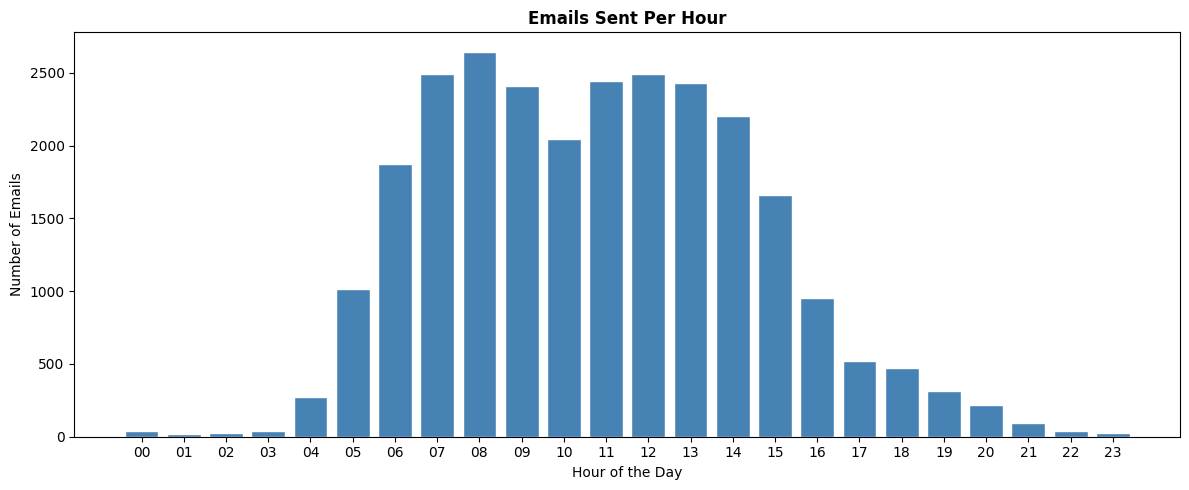

In [237]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_email_counts['Hour'], hourly_email_counts['Emails'], color='steelblue', edgecolor='white')

ax.set_title('Emails Sent Per Hour', fontweight='bold')
ax.set_xlabel('Hour of the Day')
ax.set_ylabel('Number of Emails')
ax.set_xticks(hourly_email_counts['Hour'])

plt.tight_layout()
plt.show()

I have accumulated the emails sent hourly and displayed it on the bar plot figure above to gain an understanding of the employees' emailing behavior. 

**My findings are:**

*Normal Behavior*

The majority of the total emails have been sent during worktime (usually 8-16). This is expected, as most businesses communicate through emails at standard office hours.

There are some emails sent later in the evening, but they are not seen as suspicious due to the possibility of working overtime.

*Suspicious behavior*

A noticeable trend is the many emails sent before work, in the hours between 4 AM to 7 AM. This raises concern about the purpose behind these mails and why they occur outside of standard working hours. Such activity could involve unauthorized use of company resources or exchange of information for personal benefit.

### 2: Competing Firms

Company policy prohibits **senior-level employees** from interviewing with **company competitors**. Are any employees discussing interviewing with competing firms?

In [238]:
cse['Competitors'] = cse['Recipient'].str.contains(r'(?i)williams\.com|dynegy\.com|duke-energy\.com|entergykoch\.com|entergy\.com|constellation\.com|constellationmgt\.com|estutenws11\.energy\.williams\.com')    

cse['KeyWords'] = cse['EmailBody'].str.extract(r'(?i)\b(resume|interview|application)\b')

cse['Suspicious'] = cse['Competitors'] & cse['KeyWords']

suspicious_emails = cse[cse['Suspicious']][['MessageID', 'Sender', 'Recipient', 'Competitors', 'KeyWords']]

len(suspicious_emails)

283

There are 13 emails that have been sent to the competitors and include the keywords *resume*, *interview* or *application*.

In [239]:
suspicious_emails

,MessageID,Sender,Recipient,Competitors,KeyWords
2002,11033010.1075853078416,lynn.blair@enron.com,sedavis@duke-energy.com,True,NaN
2093,8175082.1075859375771,lynn.blair@enron.com,erin.robinson@williams.com,True,NaN
2672,5130479.1075853148098,mike.carson@enron.com,ken.merideth@entergykoch.com,True,NaN
2679,3354584.1075859419980,mike.carson@enron.com,david.goodman@entergykoch.com,True,NaN
2686,30390269.1075840399347,mike.carson@enron.com,ken.merideth@entergykoch.com,True,NaN
...,...,...,...,...,...
25000,25011733.1075841590453,geir.solberg@enron.com,kurt.roseman@williams.com,True,NaN
25938,4483357.1075852522880,d..steffes@enron.com,mary.doyle@dynegy.com,True,NaN
26237,14927116.1075841608136,j..sturm@enron.com,dan.ogrady@williams.com,True,resume
26250,10657260.1075841608485,j..sturm@enron.com,michael.westbrock@williams.com,True,Resume


In [240]:
print(repr(cse['EmailData'].iloc[3911]))

"Message-ID: <29040730.1075840064819.JavaMail.evans@thyme> Date: Fri, 25 May 2001 11:02:14 -0700 (PDT) From: sean.crandall@enron.com To: sjfliflet@duke-energy.com Subject: Follow-UP Steve, Thanks for the dinner and chance to meet everyone Friday. It actually was a pleasure to talk with Nancy (rare, I think for an interview situation). I'm sorry to say I'm still in a holding pattern. There are a couple of bits of information I still need to process, but I thought I would email you with some initial numbers. I'd also like to confirm my understanding of Duke's compensation program. Base Salary: $150K-$175K/year LTI: 100% of base salary paid out in options that vest 1/3 every year. Performance Incentive: 2X to 6X base salary. No contract. Full relocation package. This is what I recall from the interview. If I'm wrong, I'd appreciate clarification. Regardless of what happens, I appreciate your time and consideration. I should be able to come to a decision next week. Thanks, Sean"


This email was sent from Sean, an employee at Enron, to the competitor Duke Energy. The message references a dinner meeting, described as "*a pleasure to talk with Nancy (rare, I think for an interview situation),*" clearly indicating that an interview occurred. Sean discusses specific details about Duke Energy's compensation package, including base salary, long-term incentives, performance bonuses, and relocation benefits. Additionally, Sean requests clarification on certain points and mentions being in the process of deciding whether to accept the offer, stating, "*I should be able to come to a decision next week.*"

The content of this email is evidence that Sean is actively negotiating or considering a role at Duke Energy, which is in direct violation of Enron's policy prohibiting senior-level employees from interviewing with competitors.

In [241]:
print(repr(cse['EmailData'].iloc[8339]))

'Message-ID: <30451932.1075840530201.JavaMail.evans@thyme> Date: Wed, 16 Jan 2002 11:28:20 -0800 (PST) From: chris.germany@enron.com To: lamoss@duke-energy.com Subject: RE: Resume Guess what? My buddy at dinergy said Mike couldn\'t talk to me if I\'m still employed by Enron. I\'m going to call him anyway just to say hello. -----Original Message----- From: "Leah A Moss" <lamoss@duke-energy.com>@ENRON Sent: Wednesday, January 16, 2002 9:33 AM To: Germany, Chris Subject: Re: Resume Mike.L.Adamcik@dynegy.com 713-767-8327 "Germany, Chris" To: "Leah A. Moss (E-mail)" <lamoss@duke-energy.com> <Chris.Germany@ cc: enron.com> Subject: Resume 01/15/2002 04:39 PM Ok, first person that gets me a job gets a steak dinner for 2 ..... to be name later depending on how much pay I get. <<chris_resume.doc>> ********************************************************************** This e-mail is the property of Enron Corp. and/or its relevant affiliate and may contain confidential and privileged material for 

This email was sent by Chris, an Enron employee, to the competitor Duke Energy. The email contains an attached file named "*chris_resume.doc,*" and explicitly states: "*first person that gets me a job gets a steak dinner for 2.*" This clearly shows that Chris is seeking employment with the competitor.

Additionally, the email includes an automated confidentiality disclaimer, emphasizing that the contents should not be disclosed outside Enron. Sharing confidential material with competitors clearly violates this policy.

Moreover, at the top of the email, Chris disrespects the competitor's intention to avoid unnecessary contact, stating, "*I'm just going to call him anyway just to say hello,*" in reference to an individual at Duke Energy. This behavior not only breaches Enron's corporate policy but also portrays the company in a negative light.

In conclusion, the email is clear evidence of Chris, an employee, violating company policy by seeking a position at a competing company and sharing sensitive information. Such actions breach Enron's internal guidelines and undermine its corporate integrity.

In [242]:
print(repr(cse['EmailData'].iloc[23849]))

"Message-ID: <32888845.1075841559397.JavaMail.evans@thyme> Date: Thu, 29 Nov 2001 08:00:45 -0800 (PST) From: cara.semperger@enron.com To: ejlanghorst@duke-energy.com Subject: RE: New Career Opportunities do you all have a job website? -----Original Message----- From: Eric Langhorst [mailto:ejlanghorst@duke-energy.com] Sent: Thursday, November 29, 2001 6:09 AM To: Semperger, Cara Subject: New Career Opportunities Cara, this sounds like something up your alley. If it doesn't come thru in a readable format, give me a fax number and I'll print it and fax to you. Eric ----- Forwarded by Eric Langhorst/SLC-ComOps/EnergyTrading/PEC on 11/29/2001 06:00 AM ----- ASHOUT01 To: 11/28/2001 cc: 05:00 PM Subject: New Career Opportunities Please review the new career opportunities listed below. To access each opportunity, please click the icon to the left of each item. Qualified employees are encouraged to apply. Recruitment efforts for this position may also include searches outside the Company. Plea

This email was sent by Cara Semperger, an employee at Enron, to the competitor Duke Energy, discussing job opportunities. The subject line, "*New Career Opportunities,*" and the body of the email show a forwarded job listing from Eric of Duke Energy to Cara. Cara’s message, "*do you all have a job website?*" clearly demonstrates an interest in exploring employment opportunities with a competing firm.

The content of this email directly breaches Enron’s corporate policy, which prohibits employees from seeking employment with competitors. Furthermore, forwarding internal communications and using company resources to inquire about external job prospects not only violates company policy but also reflects poorly on Enron’s corporate integrity.

In conclusion, Cara’s actions in sending this email constitute a clear violation of Enron’s internal guidelines. Her correspondence with a competitor regarding employment opportunities represents unauthorized use of company resources for personal benefit, thereby breaching Enron’s policies.

### 3: Test Question

My test question is:

***How Is the Work Environment at Enron?***

While researching Enron, I came across an email discussing how the top leadership treated the personnel poorly. This gave me an interest of investigating this further to see if there is a connection between the working conditions and employees seeking employment elsewhere (from task **2: Competing Firms**).

In [243]:
cse.columns

Index(['EmailData', 'EmailHeader', 'EmailBody', 'MessageID', 'Date', 'Sender',
       'Recipient', 'DateDay', 'DateMonthYear', 'Hour', 'YearMonth',
       'Competitors', 'KeyWords', 'Suspicious'],
      dtype='str')

In [244]:
# Use a distinct column name to avoid overwriting the recruitment keyword column
cse['EnvKeyWords'] = cse['EmailBody'].str.extract(r'(?i)\b(work environment|rude)\b')

cse['WorkEnvironment'] = cse['EnvKeyWords'].notnull()

workenvironment_emails = cse[cse['WorkEnvironment']][['MessageID', 'Sender', 'Recipient', 'EnvKeyWords']]

len(workenvironment_emails)

28

In [245]:
workenvironment_emails

,MessageID,Sender,Recipient,EnvKeyWords
3440,9564625.1075858842362,shelley.corman@enron.com,security.corporate@enron.com,rude
3702,22313536.1075858844629,shelley.corman@enron.com,fdjn@aol.com,rude
4094,10967914.1075853093996,martin.cuilla@enron.com,zwharton@dawray.com,rude
4711,497741.1075851621585,jeff.dasovich@enron.com,michael.tribolet@enron.com,Work environment
6277,18779762.1075840423922,chris.dorland@enron.com,dan.dorland@enron.com,rude
7685,19302632.1075840512131,chris.germany@enron.com,jhomco@minutemaid.com,rude
8535,23445248.1075852231235,c..giron@enron.com,dgiron1@houston.rr.com,Rude
9835,20215688.1075854925053,marie.heard@enron.com,lucy.ortiz@enron.com,rude
10540,8089948.1075860876461,kevin.hyatt@enron.com,jerry.hyatt@eaglegl.com,rude
10952,10891980.1075862453692,j.kaminski@enron.com,luigical@rice.edu,work environment


In [246]:
print(repr(cse['EmailData'].iloc[6277]))

'Message-ID: <18779762.1075840423922.JavaMail.evans@thyme> Date: Thu, 21 Jun 2001 06:29:40 -0700 (PDT) From: chris.dorland@enron.com To: dan.dorland@enron.com Subject: RE: Things we wish we could say at work... I like number 6. I should put a sign on my desk that says that. -----Original Message----- From: Dorland, Dan Sent: Wednesday, June 20, 2001 6:22 PM To: rod.kennedy@rbcinvestments.com; kdorland@flint-energy.com; Dorland, Chris; sutherlandcara@hotmail.com; bgabrielson@cdnam.com; Borg, Jeff; Ellis, Dave; Catherine.Cozias@dynegy.com; maengelhardt@collinsbarrow.com; Edwin.Lau@mercermc.com; Tripp, Garrett; Huculiak, Lindsey; flemingryan99@hotmail.com; shaneel.pathak@accenture.com; nicole.swartout@rbcds.com Subject: FW: Things we wish we could say at work... "George, Mike (CA - Calgary)" <migeorge@deloitte.ca> 06/20/2001 06:44 PM To: "\'thunder Dan\'" <Dan.Dorland@enron.com>, "\'K-Dog\'" <StephanieKreuz@aec.ca> cc: Subject: FW: Things we wish we could say at work... 1. Ahhh...I see th

This email was sent the 21.06.01 by Chris, an employee at Enron, to Dan, another employee at Enron. The content of the mail is filled with sarcasm and mocking tones, and its title "*Things we wish we could say at work*" tells us that the working policy tries to avoid such misbehavior towards each other. However, there is an underlying frustration or dissatisfaction among employees.

There are statements reflecting the tension in the working environment, such as:

"*I'm already visualizing the duct tape over your mouth*", telling us that there is a lack of open communication or that people are judgemental.

"*Errors have been made. Others will be blamed*", shows us the culture of blame-shifting and a lack of accountability.

"*This isn't an office. It's Hell with flourescent lighting*" and "*Chaos, panic and disorder - my work here is done*" points to discontent with the work environment and responsibilites. Associating the office with hell, clearly highlights the dissatisfaction.

In [247]:
print(repr(cse['EmailData'].iloc[16855]))

'Message-ID: <5415532.1075862409704.JavaMail.evans@thyme> Date: Tue, 13 Nov 2001 09:42:21 -0800 (PST) From: a..martin@enron.com To: john.lavorato@enron.com Subject: Employee Morale John, A dangerous environment is brewing on the trading floor. We have very large positions and people are becoming more frustrated with the work environment, uncertain about future employment and now with new information about Lay\'s "golden parachute", I am concerned that not everyone may act in the best interest of the Company (hero or zero attitude) or at a minimum may not be in the best frame of mind to trade. I hate to suggest it but do you need to reduce the people allowed to take risk for the Company? (similar to what was done when we sold HPL). The general feeling is that everyone at the top is taking care of themselves and the "little" people that have been making the money for the Company are left out in the cold. I also suggest that you move quickly to ensure appropriate compensation for key trad

This mail was sent the 13.11.01 from Martin, an employee at Enron, to John, also an employee at Enron. Martin expresses concerns about the "*dangerous environment*" brewing among employees due to increasing frustration with the work environment, uncertainty about future employment, and dissatisfaction with how management prioritizes themselves.  He mentions the "*golden parachute*" which represents the resentment towards the upper management, who are rather taking care of themselves and the "*little*" people are left out in the cold.

The email reflects low morale, with employees not acting in company's best interest and avoiding their responsibilities.

### My Findings

In conclusion, there is clear evidence of dissatisfaction among Enron employees, leading many to seek work elsewhere. Complaints about the work environment were already being raised as early as mid-June 2001. A concerning mail from mid-November 2001, highlights the uncertain and tense atmosphere within the firm during this period.

This can be connected to the previous mails we have looked at, which was sent shortly afterwards. Thus, further supports the theory that poor treatment of employees and toxic work culture led to their desire to leave the company, and explore opportunities at competing organizations.